In [ ]:
# CamScanner
# Image Transformation - Translate, Rotate, Resize, Crop
# Perpective Transform

In [6]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

In [7]:
img = cv2.imread("z1.png")

In [8]:
img.shape

(1500, 2667, 3)

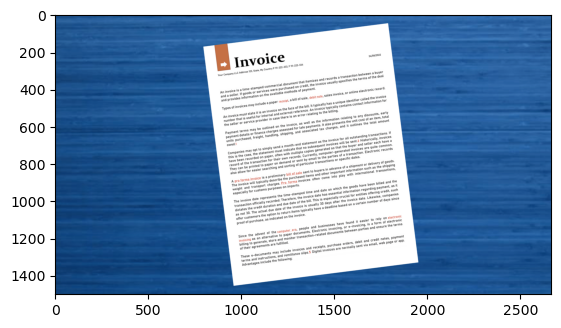

In [9]:
plt.imshow(img)
plt.show()

In [10]:
rows, cols = img.shape[:2]

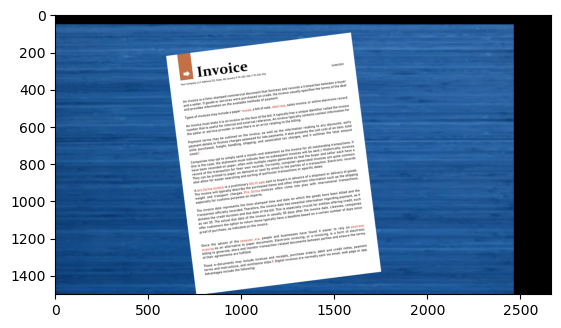

In [11]:
# Translate Image
# create translation matrix
# Format :  [[1, 0, tx],
#            [0, 1, ty]]
# tx - shift in x direction
# ty - shift in y direction
matrix = np.float32([[1, 0, -200],
                     [0, 1, 50]])

# Apply translation
# params : (image, translation matrix, output image size)
translated = cv2.warpAffine(img, matrix, (cols, rows))
plt.imshow(translated)
plt.show()

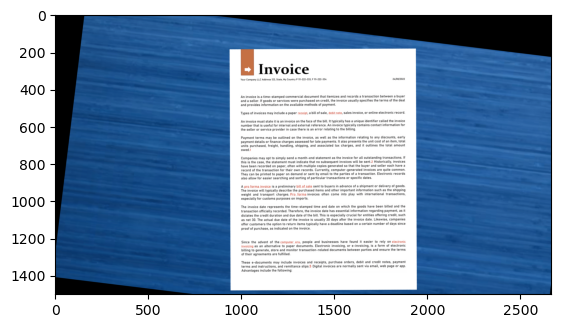

In [12]:
# Rotation
# Center of rotation 

center = (rows//2, cols//2)
# Parameters : (center, angle of rotation, scale factor)
# angle of rotation - positive value - counter clockwise, negative value - clockwise (in degree)
# scale  - zoom (default =1 )

matrix = cv2.getRotationMatrix2D(center, -7, 1)
rotated = cv2.warpAffine(img, matrix, (cols, rows))
plt.imshow(rotated)
plt.show()

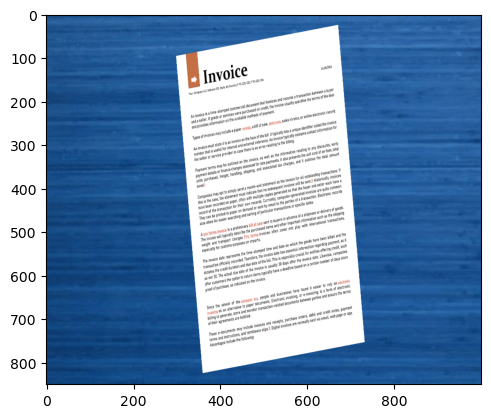

In [13]:
# Resize image
resized = cv2.resize(img, (1000, 850))
# center = (rows//2, cols//2)
# matrix = cv2.getRotationMatrix2D(center, -7, 1)
# rotated = cv2.warpAffine(img, matrix, (cols, rows))
plt.imshow(resized)
plt.show()

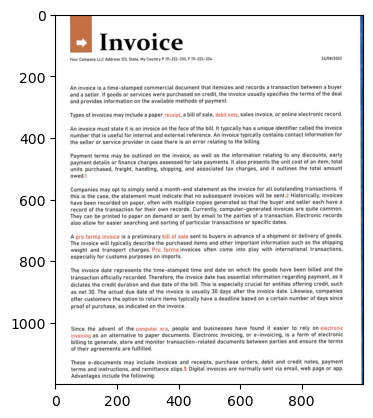

In [14]:
# rotated [start_y:end_y, start_x:end_x]
# first = row(height - y)
# second = column(width - x)
cropped = rotated[200:1400, 950:1950]

plt.imshow(cropped)
plt.show()

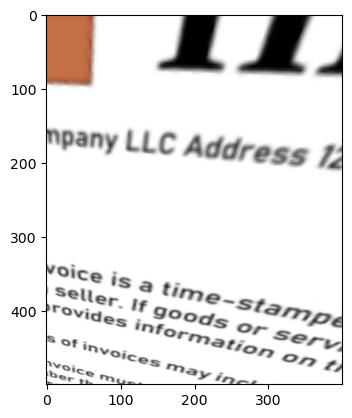

In [15]:
# Perspective Transform
# Convert titled document into - top-down flat view
# Source points - [top-left, top-right, bottom-right, bottom-left]
points1 = np.float32([[100, 100], [200, 100], [300, 300], [80, 420]])
# Destination points - [top-left, top-right, bottom-right, bottom-left]
points2 = np.float32([[0, 0], [400, 0], [400, 500], [0, 500]])

matrix = cv2.getPerspectiveTransform(points1, points2)
warped = cv2.warpPerspective(cropped, matrix, [400, 500])
plt.imshow(warped)
plt.show()

In [2]:
import cv2

In [6]:
cap = cv2.VideoCapture(0)
i = 0
while True:
  flag , frame = cap.read()
  if not flag:
    print("No frame detected")
    break
  cv2.imshow("Webcam", frame)
  i+=1
  cv2.imwrite(f'images/img_{i}.jpg', frame)
  # wait for 25 ms (controls the speed of the video)
  key = cv2.waitKey(25) & 0xFF
  # 27 is the ASCII code for the ESC key
  if key == 27:
    break
cap.release()
cv2.destroyAllWindows()

